In [57]:
import pystormtracker as pst
import numba
import numpy as np
import xarray as xr

import sys
import os

import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm
import seaborn as sns
from scipy import stats
import cmocean
import pandas as pd
import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm


In [58]:
ds = xr.open_dataset("/Users/asgerthormann/Documents/uni/master/master_code/data/wind_speed/850hpa_uv_wind_6h_NA.nc")

In [59]:
ds

<xarray.Dataset> Size: 7MB
Dimensions:         (valid_time: 12, pressure_level: 1, latitude: 181,
                     longitude: 401)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 96B 1999-12-02 ... 1999-12-04...
    expver          (valid_time) <U4 192B ...
  * pressure_level  (pressure_level) float64 8B 850.0
  * latitude        (latitude) float64 1kB 75.0 74.75 74.5 ... 30.5 30.25 30.0
  * longitude       (longitude) float64 3kB -70.0 -69.75 -69.5 ... 29.75 30.0
    number          int64 8B ...
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 3MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-23T19:43 GRIB to CDM+CF via cfgrib-0.9.1...

In [60]:
div, vort = pst.preprocessing.kinematics.compute_vorticity_divergence(ds['u'], ds['v'])

In [61]:
lat_s, lat_n = 30.0, 75.0        
lon_w, lon_e = -70, 30

vor = (
    vort.squeeze("pressure_level", drop=True)
        .drop_vars(["expver", "number"], errors="ignore")
        .rename({"valid_time": "time"})
        .assign_coords(longitude=((vort.longitude + 180) % 360) - 180)   # 0–360 -> -180–180
        .sortby("longitude")
        .sel(latitude=slice(lat_n, lat_s), longitude=slice(lon_w, lon_e))  # lat is descending
        .transpose("time", "latitude", "longitude")
        .rename("vo")
)

<xarray.DataArray 'vo' (time: 12, latitude: 181, longitude: 401)> Size: 3MB
array([[[-6.08596092e-05, -6.08596092e-05, -6.08596092e-05, ...,
         -6.08596092e-05, -6.08596092e-05, -6.08596092e-05],
        [ 7.97958637e-05,  8.04404626e-05,  8.09990743e-05, ...,
          7.73973516e-05,  7.82690258e-05,  7.90703198e-05],
        [ 8.23533701e-05,  9.08463844e-05,  9.89546606e-05, ...,
          5.51142257e-05,  6.44301472e-05,  7.35292488e-05],
        ...,
        [ 1.62063618e-04,  1.60708645e-04,  1.58864321e-04, ...,
          1.63230245e-04,  1.63317804e-04,  1.62931581e-04],
        [ 1.98042922e-04,  1.96724592e-04,  1.95288667e-04, ...,
          2.01277886e-04,  2.00320705e-04,  1.99242058e-04],
        [ 6.03244116e-05,  6.03244116e-05,  6.03244116e-05, ...,
          6.03244116e-05,  6.03244116e-05,  6.03244116e-05]],

       [[-4.99120215e-05, -4.99120215e-05, -4.99120215e-05, ...,
         -4.99120215e-05, -4.99120215e-05, -4.99120215e-05],
        [ 9.86562882e-05,  9.95043083e-05,  1.00270387e-04, ...,
          9.56726362e-05,  9.67351370e-05,  9.77314776e-05],
        [ 7.32653352e-05,  8.20059140e-05,  9.04624103e-05, ...,
          4.59025287e-05,  5.51559788e-05,  6.42963059e-05],
...
          2.58723994e-05,  2.62661215e-05,  2.64314149e-05],
        [ 1.02682199e-04,  1.03236962e-04,  1.03786821e-04, ...,
          1.00995356e-04,  1.01560690e-04,  1.02123209e-04],
        [-3.17568520e-05, -3.17568520e-05, -3.17568520e-05, ...,
         -3.17568520e-05, -3.17568520e-05, -3.17568520e-05]],

       [[-2.41848702e-05, -2.41848702e-05, -2.41848702e-05, ...,
         -2.41848702e-05, -2.41848702e-05, -2.41848702e-05],
        [-6.08340924e-05, -5.83152905e-05, -5.57805943e-05, ...,
         -6.82883619e-05, -6.58213467e-05, -6.33363452e-05],
        [-9.81686571e-06, -9.94427683e-06, -1.01238420e-05, ...,
         -9.81425637e-06, -9.74557224e-06, -9.74846807e-06],
        ...,
        [ 1.84558467e-05,  2.05022443e-05,  2.23293318e-05, ...,
          1.10895980e-05,  1.37379029e-05,  1.61976423e-05],
        [ 7.84435251e-05,  7.90010527e-05,  7.95651504e-05, ...,
          7.68290847e-05,  7.73556749e-05,  7.78944450e-05],
        [-5.03797783e-05, -5.03797783e-05, -5.03797783e-05, ...,
         -5.03797783e-05, -5.03797783e-05, -5.03797783e-05]]],
      shape=(12, 181, 401), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 96B 1999-12-02 ... 1999-12-04T18:00:00
  * latitude   (latitude) float64 1kB 75.0 74.75 74.5 74.25 ... 30.5 30.25 30.0
  * longitude  (longitude) float64 3kB -70.0 -69.75 -69.5 ... 29.5 29.75 30.0
    number     int64 8B 0
Attributes:
    units:      s^-1
    long_name:  relative vorticity

In [62]:
vor.attrs = {"units": "s^-1", "long_name": "relative vorticity"}
print(vor.attrs)

{'units': 's^-1', 'long_name': 'relative vorticity'}


### Tracker sanity checks

The checks below make the units, cadence, and effective Hodges settings explicit. In `pystormtracker 0.7.0`, the default latitude-zone table caps the effective `dmax` at 6.5 degrees for this domain, so `dmax=9.0` is not the value actually used.

In [63]:
time_step = np.median(np.diff(vor.time.values))
print('shape:', dict(vor.sizes))
print('time step:', time_step)
print('vorticity units:', vor.attrs.get('units'))
print('vorticity range [s^-1]:', float(vor.min()), float(vor.max()))
assert vor.attrs.get('units') == 's^-1'
assert time_step == np.timedelta64(6, 'h')

shape: {'time': 12, 'latitude': 181, 'longitude': 401}
time step: 21600000000000 nanoseconds
vorticity units: s^-1
vorticity range [s^-1]: -0.0002482015697751194 0.0003047614300157875


In [69]:
tracker = pst.HodgesTracker(min_track_points=10, taper_points=10, lmin=5, lmax=42, dmax=9, min_object_grid_points=18)
tracks = tracker.track(
    vor.to_dataset(name='vo'),
    "vo",
    detection_mode="max",
    object_threshold=1e-5,
    time_step=np.timedelta64(6, "h"),
)

for track in tracks:
    if len(track) >= 8:
        print(track.track_id, len(track))

tracks.write("tracks_NA_vor.trackjson")

7 12
15 11
105 10


In [70]:
print('effective dmax:', tracker.dmax)
print('configured lmin/lmax:', tracker.lmin, tracker.lmax)
print('configured min object grid points:', tracker.min_object_grid_points)
print('tracks retained:', len(tracks))
print('track lengths:', sorted((len(track) for track in tracks), reverse=True))

effective dmax: 6.5
configured lmin/lmax: 5 42
configured min object grid points: 18
tracks retained: 3
track lengths: [12, 11, 10]


In [71]:
#import pandas as pd

#def haversine_km(lon1, lat1, lon2, lat2):
#    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
#    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
##    return 2 * 6371 * np.arcsin(np.sqrt(a))

#frags = sorted(tracks, key=lambda t: t.times[0])
#for a, b in zip(frags, frags[1:]):
#    t_a_end = pd.to_datetime(a.times[-1])
#    t_b_start = pd.to_datetime(b.times[0])
#    gap_h = (t_b_start - t_a_end) / pd.Timedelta(hours=1)
#    dist_km = haversine_km(a.lons[-1], a.lats[-1], b.lons[0], b.lats[0])
#    if 0 < gap_h < 24 and dist_km < 1500:
#        print(a.track_id, b.track_id, gap_h, "h gap,", dist_km, "km")

In [72]:
first = next(iter(tracks))
print(type(first), [a for a in dir(first) if not a.startswith("_")])

<class 'pystormtracker.models.tracks.Track'> ['abs_dist', 'lats', 'lons', 'point_slice', 'times', 'track_id', 'variables']


/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


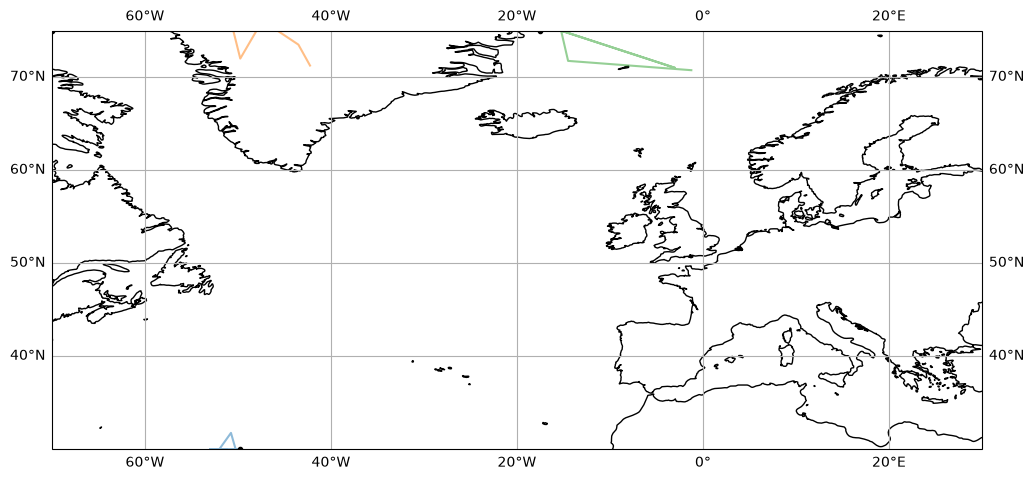

In [73]:

min_len=3
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.coastlines()
ax.gridlines(draw_labels=True)
ax.set_extent([lon_w, lon_e, lat_s, lat_n], crs=ccrs.PlateCarree())

for track in tracks:
    if len(track) >= min_len:
        ax.plot(track.lons, track.lats, transform=ccrs.PlateCarree(), alpha=0.5)
        ax.plot(track.lons[0], track.lats[0], "o", ms=3, color="k", transform=ccrs.PlateCarree())  # genesis point

